Dataset: DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Training samples: 67349
Validation samples: 872
Testing samples: 1821

Training shape: (67349, 100)
Validation shape: (872, 100)
Testing shape: (1821, 100)

Sample Review:
hide new secretions from the parental units

Sample Token Sequence:
[4429, 84, 1, 34, 2, 7167, 8879]

Label Distribution:
1    37569
0    29780
Name: count, dtype: int64


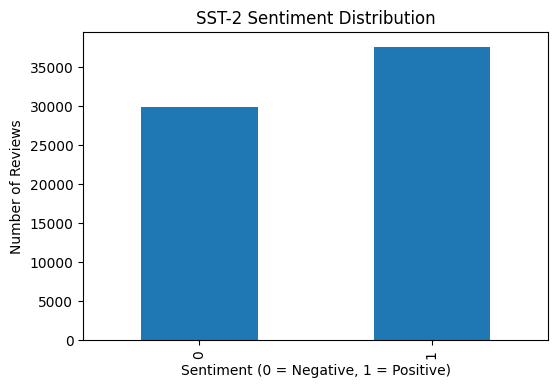

In [5]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
print("Yamini M")
print("24BAD131")
ds = load_dataset("stanfordnlp/sst2")

train_data = ds["train"]
val_data = ds["validation"]
test_data = ds["test"]

X_train = np.array(train_data["sentence"])
y_train = np.array(train_data["label"])

X_val = np.array(val_data["sentence"])
y_val = np.array(val_data["label"])

X_test = np.array(test_data["sentence"])
y_test = np.array(test_data["label"])

def clean_text(text):
    text = text.lower()
    text = tf.strings.regex_replace(text, r"[^a-zA-Z\s]", "")
    text = tf.strings.regex_replace(text, r"\s+", " ")
    return text.numpy().decode("utf-8").strip()

X_train = np.array([clean_text(x) for x in X_train])
X_val = np.array([clean_text(x) for x in X_val])
X_test = np.array([clean_text(x) for x in X_test])

VOCAB_SIZE = 10000
MAX_LENGTH = 100

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Dataset:", ds)
print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))
print("\nTraining shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Testing shape:", X_test_pad.shape)

print("\nSample Review:")
print(X_train[0])

print("\nSample Token Sequence:")
print(X_train_seq[0])

print("\nLabel Distribution:")
print(pd.Series(y_train).value_counts())

plt.figure(figsize=(6,4))
pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
plt.title("SST-2 Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")
plt.show()

In [6]:
from tensorflow.keras.layers import Embedding
print("Yamini M")
print("24BAD131")
EMBEDDING_DIM = 128

embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)

sample_input = tf.constant(X_train_pad[:1])
sample_embedding = embedding_layer(sample_input)

print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Sequence Length:", MAX_LENGTH)
print("Embedding Dimension:", EMBEDDING_DIM)

print("\nInput Sequence Shape:")
print(sample_input.shape)

print("\nEmbedding Representation Shape:")
print(sample_embedding.shape)

print("\nSample Embedding Values:")
print(sample_embedding.numpy()[0][:2])

Vocabulary Size: 10000
Maximum Sequence Length: 100
Embedding Dimension: 128

Input Sequence Shape:
(1, 100)

Embedding Representation Shape:
(1, 100, 128)

Sample Embedding Values:
[[-0.0171598   0.00557909  0.02358967  0.03424478 -0.02287253  0.01579687
  -0.00589701 -0.00435323 -0.04033743  0.03195944 -0.04677415 -0.02576714
  -0.03971201  0.00744297 -0.04432235 -0.00411122 -0.00636666 -0.02551075
  -0.00450158 -0.01999282 -0.01122    -0.00930787 -0.04932445  0.01012136
   0.03128556  0.01114113 -0.02550421  0.01906073 -0.03090662 -0.02472724
  -0.00047351 -0.00976113 -0.00485486  0.03572873  0.03304733 -0.04967759
   0.01874665 -0.00543534  0.04842055 -0.00325399 -0.0158507   0.03089161
  -0.03260627 -0.02751163 -0.03587504 -0.03949894  0.00664397 -0.00923752
   0.00328141 -0.01922398 -0.02577928  0.01426125 -0.04581503  0.04373835
   0.02376861  0.04250321 -0.02214001  0.04714869  0.01727216  0.0176018
   0.02380626 -0.01590624 -0.01836341 -0.00597521  0.03171481  0.02101516
  -0.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
print("Yamini M")
print("24BAD131")
EMBEDDING_DIM = 64

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, MAX_LENGTH))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 277s 295ms/step - accuracy: 0.8440 - loss: 0.3490 - val_accuracy: 0.8942 - val_loss: 0.2489
Epoch 2/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 249s 279ms/step - accuracy: 0.9246 - loss: 0.1879 - val_accuracy: 0.9097 - val_loss: 0.2240
Epoch 3/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 258s 289ms/step - accuracy: 0.9453 - loss: 0.1323 - val_accuracy: 0.9147 - val_loss: 0.2333
Epoch 4/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 254s 280ms/step - accuracy: 0.9552 - loss: 0.1049 - val_accuracy: 0.9115 - val_loss: 0.2514
Epoch 5/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 249s 278ms/step - accuracy: 0.9609 - loss: 0.0889 - val_accuracy: 0.9155 - val_loss: 0.2800
Epoch 6/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 257s 288ms/step - accuracy: 0.9660 - loss: 0.0753 - val_accuracy: 0.9136 - val_loss: 0.3059
Epoch 7/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 255s 279ms/step - accuracy: 0.9695 - loss: 0.0672 - val_accuracy: 0.9142 - val_loss: 0.3339
Epoch 8/8
895/895 ━━━━━━━━━━━━━━━━━━━━ 261s 278ms/step - accuracy: 0.9730 - loss: 0

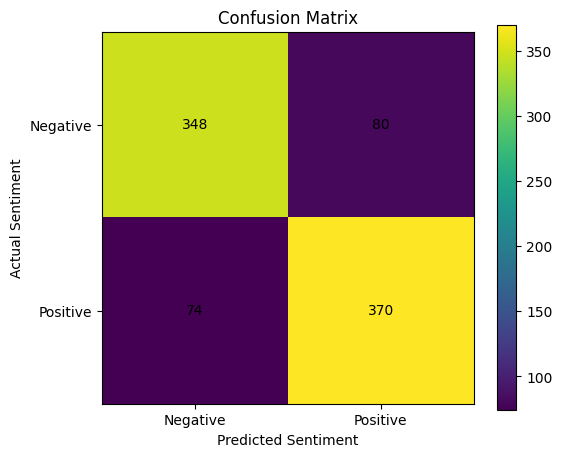

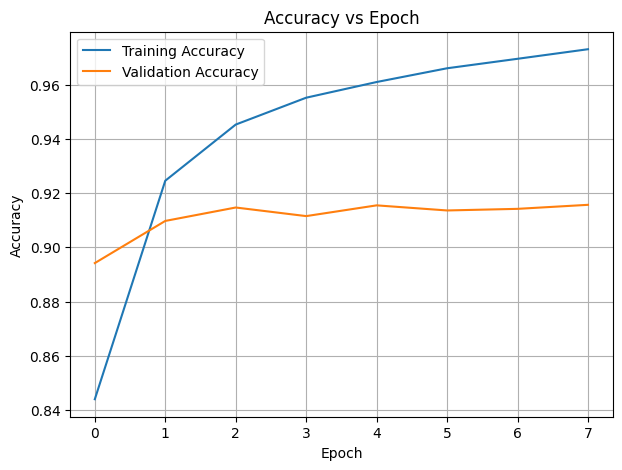

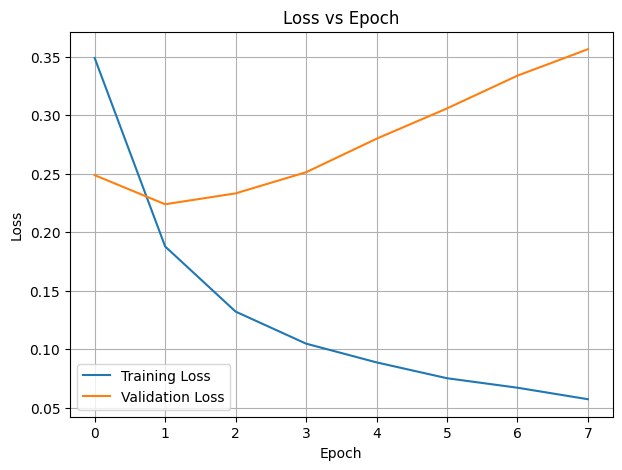


ACTUAL VS PREDICTED
------------------------


,Actual Sentiment,Predicted Sentiment,Probability
0,Positive,Positive,1.0000
1,Negative,Negative,0.0000
2,Positive,Positive,1.0000
3,Positive,Negative,0.0201
4,Negative,Negative,0.0001
5,Positive,Positive,1.0000
6,Negative,Negative,0.0133
7,Negative,Negative,0.0563
8,Positive,Negative,0.2785
9,Negative,Negative,0.0000



SAMPLE SENTIMENT PREDICTIONS
------------------------

Review: This movie was absolutely amazing and I really enjoyed it.
Predicted Sentiment: Positive
Probability: 1.0

Review: The movie was boring, disappointing and a complete waste of time.
Predicted Sentiment: Negative
Probability: 0.0005

Review: Excellent acting, wonderful story and fantastic direction.
Predicted Sentiment: Positive
Probability: 0.9999

Review: I hated this movie. It was terrible and very poorly made.
Predicted Sentiment: Negative
Probability: 0.0


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd
print("Yamini M")
print("24BAD131")
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=8,
    batch_size=64,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

y_pred_probability = model.predict(
    X_test_pad,
    verbose=0
).flatten()

y_pred = (y_pred_probability >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\nMODEL EVALUATION")
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))
print("Accuracy      :", round(accuracy, 4))
print("Precision     :", round(precision, 4))
print("Recall        :", round(recall, 4))
print("F1-Score      :", round(f1, 4))

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

comparison = pd.DataFrame({
    "Actual Sentiment": [
        "Positive" if x == 1 else "Negative"
        for x in y_test[:20]
    ],
    "Predicted Sentiment": [
        "Positive" if x == 1 else "Negative"
        for x in y_pred[:20]
    ],
    "Probability": np.round(y_pred_probability[:20], 4)
})

print("\nACTUAL VS PREDICTED")
display(comparison)

def predict_sentiment(review):
    cleaned_review = clean_text(review)

    sequence = tokenizer.texts_to_sequences([cleaned_review])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probability = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    return sentiment, float(probability)

sample_reviews = [
    "This movie was absolutely amazing and I really enjoyed it.",
    "The movie was boring, disappointing and a complete waste of time.",
    "Excellent acting, wonderful story and fantastic direction.",
    "I hated this movie. It was terrible and very poorly made."
]

print("\nSAMPLE SENTIMENT PREDICTIONS")
for review in sample_reviews:
    sentiment, probability = predict_sentiment(review)

    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment)
    print("Probability:", round(probability, 4))